In [1]:
import os

import xarray as xr
import numpy as np

# %matplotlib widget
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
# TkAgg is usually built-in and very fast

import sys

%load_ext autoreload
%autoreload 1

sys.path.insert(0, '../../instrument/')
from Agilent.instr_N9928A import N9928A
from Valon.instr_Valon5015 import Valon5015

sys.path.insert(0, '../../pattern/')
%aimport helper_sweep
from helper_sweep import do_sweep

In [2]:
rf_address = "10.0.100.24"
rf = Valon5015(rf_address)

Connected to Valon_5015 [10.0.100.24:23].


In [58]:
_address = "10.0.100.110"
_instr = N9928A(_address)

Connected to N9928A [10.0.100.110:5025].


In [81]:
rf.frequency(8.428e9)
rf.power(-30)
rf.output(1)

In [82]:
_instr.reference('EXT')
_instr.start_frequency(480e6)
_instr.stop_frequency(550e6)
_instr.if_frequency(1e3)
_instr.average(10, mode='sweep')
_instr.points(1001)
_instr.power(-15)

In [83]:
config_device = [rf, _instr]
config_sweep = [
    [
        [rf.power, 'power_dbm', np.arange(-30,0+1e-9,1)]
    ],
    [
        [_instr.power, 'power_dbm', np.array([-15])]
    ]
]

In [84]:
file_path = os.path.join(os.getcwd(), 'wavepool_bolo_1.zarr')
do_sweep(config_device, config_sweep, _instr.get_trace, file_path)
rf.output(0)

100%|██████████| 31/31 [15:47<00:00, 30.55s/it]


In [85]:
file_path = 'wavepool_bolo_1.zarr'

with xr.open_zarr(file_path, consolidated=False) as f:
    raw_data = f['S21']

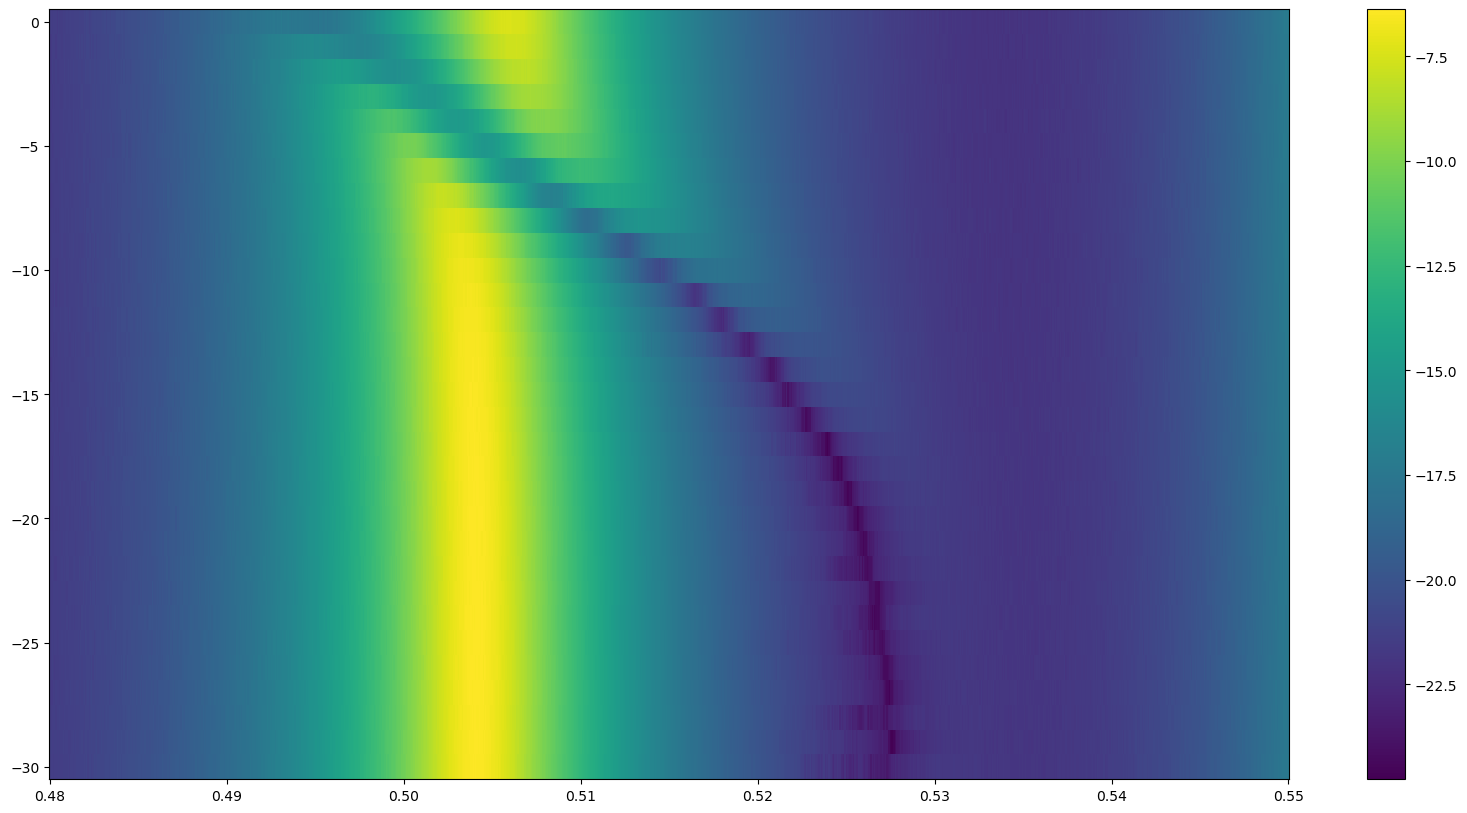

In [88]:
plt.figure(figsize = (20,10))

try:
    plt.pcolormesh(raw_data.N9928A_frequency_hz/1e9, raw_data.Valon_5015_power_dbm, 20*np.log10(np.abs(raw_data)).squeeze())
    plt.colorbar()

    # for _power in raw_data.Valon_5015_power_dbm:
    #     plt.plot(raw_data.N9928A_frequency_hz/1e9, 20*np.log10(np.abs(raw_data.sel(Valon_5015_power_dbm=_power).squeeze())))
except:
    plt.plot(raw_data.N9928A_frequency_hz/1e9, 20*np.log10(np.abs(raw_data.squeeze())))

# plt.vlines(f_list, -50, -10, color='k')

plt.show()